### Генерация поэзии с помощью нейронных сетей: шаг 1
##### Автор: [Радослав Нейчев](https://www.linkedin.com/in/radoslav-neychev/), @neychev

Ваша основная задача: научиться генерироват стихи с помощью простой рекуррентной нейронной сети (Vanilla RNN). В качестве корпуса текстов для обучения будет выступать роман в стихах "Евгений Онегин" Александра Сергеевича Пушкина.

In [1]:
# do not change the code in the block below
# __________start of block__________
import string
import os
from random import sample

import numpy as np
import torch, torch.nn as nn
import torch.nn.functional as F

from IPython.display import clear_output

import matplotlib.pyplot as plt
# __________end of block__________

In [2]:
# do not change the code in the block below
# __________start of block__________
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
print('{} device is available'.format(device))
# __________end of block__________

cpu device is available


#### 1. Загрузка данных.

In [3]:
# do not change the code in the block below
# __________start of block__________
import urllib.request

url = "https://raw.githubusercontent.com/neychev/small_DL_repo/master/datasets/onegin.txt"
urllib.request.urlretrieve(url, "onegin.txt")
    
with open('onegin.txt', 'r', encoding='utf-8') as iofile:
    text = iofile.readlines()
    
text = "".join([x.replace('\t\t', '').lower() for x in text])
# __________end of block__________

#### 2. Построение словаря и предобработка текста
В данном задании требуется построить языковую модель на уровне символов. Приведем весь текст к нижнему регистру и построим словарь из всех символов в доступном корпусе текстов. Также добавим токен `<sos>`.

In [4]:
# do not change the code in the block below
# __________start of block__________
tokens = sorted(set(text.lower())) + ['<sos>']
num_tokens = len(tokens)

assert num_tokens == 84, "Check the tokenization process"

token_to_idx = {x: idx for idx, x in enumerate(tokens)}
idx_to_token = {idx: x for idx, x in enumerate(tokens)}

assert len(tokens) == len(token_to_idx), "Mapping should be unique"

print("Seems fine!")


text_encoded = [token_to_idx[x] for x in text]
# __________end of block__________

Seems fine!


__Ваша задача__: обучить классическую рекуррентную нейронную сеть (Vanilla RNN) предсказывать следующий символ на полученном корпусе текстов и сгенерировать последовательность длины 100 для фиксированной начальной фразы.

Вы можете воспользоваться кодом с занятие №6 или же обратиться к следующим ссылкам:
* Замечательная статья за авторством Andrej Karpathy об использовании RNN: [link](http://karpathy.github.io/2015/05/21/rnn-effectiveness/)
* Пример char-rnn от Andrej Karpathy: [github repo](https://github.com/karpathy/char-rnn)
* Замечательный пример генерации поэзии Шекспира: [github repo](https://github.com/spro/practical-pytorch/blob/master/char-rnn-generation/char-rnn-generation.ipynb)

Данное задание является достаточно творческим. Не страшно, если поначалу оно вызывает затруднения. Последняя ссылка в списке выше может быть особенно полезна в данном случае.

Далее для вашего удобства реализована функция, которая генерирует случайный батч размера `batch_size` из строк длиной `seq_length`. Вы можете использовать его при обучении модели.

In [5]:
# do not change the code in the block below
# __________start of block__________
batch_size = 256
seq_length = 100
start_column = np.zeros((batch_size, 1), dtype=int) + token_to_idx['<sos>']

def generate_chunk():
    global text_encoded, start_column, batch_size, seq_length

    start_index = np.random.randint(0, len(text_encoded) - batch_size*seq_length - 1)
    data = np.array(text_encoded[start_index:start_index + batch_size*seq_length]).reshape((batch_size, -1))
    yield np.hstack((start_column, data))
# __________end of block__________    

Пример батча:

In [6]:
next(generate_chunk())

array([[83, 63, 67, ...,  1, 56, 45],
       [83, 58, 53, ..., 59, 68, 50],
       [83, 62, 63, ..., 49, 61, 64],
       ...,
       [83, 55, 56, ...,  1, 56, 73],
       [83,  0, 64, ..., 78,  1, 43],
       [83, 63, 72, ..., 57,  7,  1]])

Далее вам предстоит написать код для обучения модели и генерации текста.

Step 0, loss: 4.4449
Step 100, loss: 2.8252
Step 200, loss: 2.3467
Step 300, loss: 2.1818
Step 400, loss: 2.0752
Step 500, loss: 1.9875
Step 600, loss: 1.9219
Step 700, loss: 1.8649
Step 800, loss: 1.8155
Step 900, loss: 1.7588
Step 1000, loss: 1.7164
Step 1100, loss: 1.6722
Step 1200, loss: 1.6271
Step 1300, loss: 1.6076
Step 1400, loss: 1.5583
Step 1500, loss: 1.5387
Step 1600, loss: 1.5031
Step 1700, loss: 1.4740
Step 1800, loss: 1.4407
Step 1900, loss: 1.4220
Step 2000, loss: 1.3917
Step 2100, loss: 1.3510
Step 2200, loss: 1.3621
Step 2300, loss: 1.3138
Step 2400, loss: 1.2949


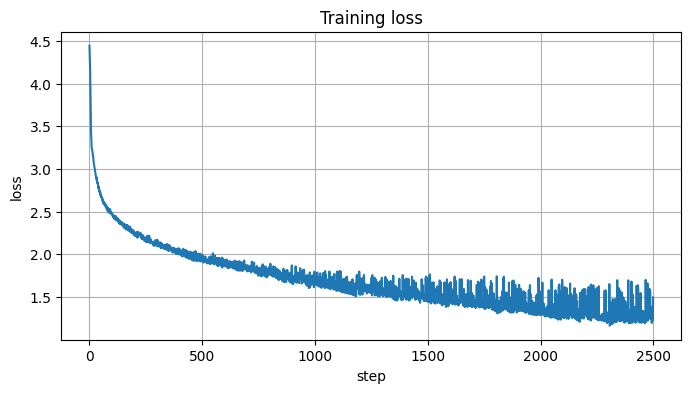

In [7]:
class CharRNN(nn.Module):
    def __init__(self, vocab_size, emb_size=64, hidden_size=256, num_layers=1, dropout=0.0):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, emb_size)
        self.rnn = nn.RNN(
            input_size=emb_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            dropout=dropout if num_layers > 1 else 0.0,
            batch_first=True,
        )
        self.output = nn.Linear(hidden_size, vocab_size)

    def forward(self, x, h=None):
        x = self.embedding(x)
        out, h = self.rnn(x, h)
        logits = self.output(out)
        return logits, h


model = CharRNN(num_tokens, emb_size=64, hidden_size=256, num_layers=1).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()

num_steps = 2500
loss_history = []

for step in range(num_steps):
    batch = next(generate_chunk())
    x = torch.tensor(batch[:, :-1], dtype=torch.long, device=device)
    y = torch.tensor(batch[:, 1:], dtype=torch.long, device=device)

    optimizer.zero_grad()
    logits, _ = model(x)
    loss = criterion(logits.reshape(-1, num_tokens), y.reshape(-1))
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
    optimizer.step()

    loss_history.append(loss.item())

    if step % 100 == 0:
        print(f"Step {step}, loss: {np.mean(loss_history[-100:]):.4f}")

plt.figure(figsize=(8, 4))
plt.plot(loss_history)
plt.title("Training loss")
plt.xlabel("step")
plt.ylabel("loss")
plt.grid(True)
plt.show()

В качестве иллюстрации ниже доступен график значений функции потерь, построенный в ходе обучения авторской сети (сам код для ее обучения вам и предстоит написать).

Шаблон функции `generate_sample` также доступен ниже. Вы можете как дозаполнить его, так и написать свою собственную функцию с нуля. Не забывайте, что все примеры в обучающей выборке начинались с токена `<sos>`.

In [13]:
def generate_sample(char_rnn, seed_phrase=None, max_length=200, temperature=1.0, device=device):
    '''
    The function generates text given a phrase of length at least SEQ_LENGTH.
    :param seed_phrase: prefix characters. The RNN is asked to continue the phrase
    :param max_length: maximum output length, including seed_phrase
    :param temperature: coefficient for sampling.  higher temperature produces more chaotic outputs,
                        smaller temperature converges to the single most likely output
    '''
    
    if seed_phrase is not None:
        x_sequence = [token_to_idx['<sos>']] + [token_to_idx[token] for token in seed_phrase]
    else: 
        x_sequence = [token_to_idx['<sos>']]

    x_sequence = torch.tensor([x_sequence], dtype=torch.int64).to(device)
    
    #feed the seed phrase, if any
            
    was_training = char_rnn.training
    char_rnn.eval()

    with torch.no_grad():
        h = None
        if x_sequence.shape[1] > 1:
            for i in range(x_sequence.shape[1] - 1):
                _, h = char_rnn(x_sequence[:, i:i+1], h)

        current = x_sequence[:, -1:]

        while x_sequence.shape[1] < max_length:
            logits, h = char_rnn(current, h)
            next_token_logits = logits[:, -1, :] / max(temperature, 1e-6)
            probs = F.softmax(next_token_logits, dim=-1)
            next_token = torch.multinomial(probs, num_samples=1)
            x_sequence = torch.cat([x_sequence, next_token], dim=1)
            current = next_token

    if was_training:
        char_rnn.train()
    
    return ''.join([tokens[ix] for ix in x_sequence.cpu().data.numpy()[0]])

Пример текста сгенерированного обученной моделью доступен ниже. Не страшно, что в тексте много несуществующих слов. Используемая модель очень проста: это простая классическая RNN.

In [14]:
print(generate_sample(model, ' мой дядя самых честных правил', max_length=500, temperature=0.8))

<sos> мой дядя самых честных правилил.
пирий разговор она,
к постерки раду;
день и веки мечты,
теце и нейдет утрение:
зато любовь и приблет
и обороче!
мечтам заклонник ничимать?
у вмоши довольные страстной
загод нетрижуется темно;
залокотойный лоною,
нетупи всех вечера и след,
и вот уж надразнала мя?. я слов, конечно,
а шуткую кревосклоне
благословил смешал,
которы в горитья своем к стихи,
награстливо не людь к глуши своя,
как тоткровных франя, трубки
и наконецый воих.
всё вы, про тишины;
татьяна ра


### Сдача задания
Сгенерируйте десять последовательностей длиной 500, используя строку ' мой дядя самых честных правил'. Температуру для генерации выберите самостоятельно на основании визуального качества генериуремого текста. Не забудьте удалить все технические токены в случае их наличия.

Сгенерированную последовательность сохрание в переменную `generated_phrase` и сдайте сгенерированный ниже файл в контест.

In [15]:
seed_phrase = ' мой дядя самых честных правил'

In [16]:
generated_phrases = [
    generate_sample(
        model,
        seed_phrase,
        max_length=500,
        temperature=0.8,
    ).replace('<sos>', '')[:500]
    for _ in range(10)
]

for i in range(len(generated_phrases)):
    if len(generated_phrases[i]) < 500:
        generated_phrases[i] = generated_phrases[i] + ' ' * (500 - len(generated_phrases[i]))

print('Generated phrases:', len(generated_phrases), 'Length of first phrase:', len(generated_phrases[0]))

Generated phrases: 10 Length of first phrase: 500


In [17]:
# do not change the code in the block below
# __________start of block__________

import json
if 'generated_phrases' not in locals():
    raise ValueError("Please, save generated phrases to `generated_phrases` variable")

for phrase in generated_phrases:

    if not isinstance(phrase, str):
        raise ValueError("The generated phrase should be a string")

    if len(phrase) != 500:
        raise ValueError("The `generated_phrase` length should be equal to 500")

    assert all([x in set(tokens) for x in set(list(phrase))]), 'Unknown tokens detected, check your submission!'
    

submission_dict = {
    'token_to_idx': token_to_idx,
    'generated_phrases': generated_phrases
}

with open('submission_dict.json', 'w') as iofile:
    json.dump(submission_dict, iofile)
print('File saved to `submission_dict.json`')
# __________end of block__________

File saved to `submission_dict.json`


На этом задание завершено. Поздравляем!